<a href="https://colab.research.google.com/github/ilinthm26/Gender-Inclusivity-and-Pay-Gap-Analysis/blob/main/IBM_Gender_Inclusivity_and_Pay_Gap_EDA_KPI_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***IBM_Gender_Inclusivity_and_Pay_Gap_EDA_KPI_Analysis***

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Cleaned Data

Dataset is called processed_hr_data, which is generated when the [IBM_Gender_Inclusivity_and_Pay_Gap_Data_Understanding.ipynb](https://colab.research.google.com/drive/10dphrJcNbKPQ37v_487H22X6A9xjc_ly#scrollTo=9RyjBJNvCXsb&forceEdit=true&sandboxMode=true) is excuted. Replace with your file name.

In [2]:
df= pd.read_csv(r'/content/processed_hr_data.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeBand,TenureBand,IsLeader,leadership_level
0,41,Yes,Travel_Rarely,1102,Sales,2,Life Sciences,1,2,Female,...,8,1,6,4,0,5,36-45,6-10 Years,0,Individual Contributor
1,49,No,Travel_Frequently,279,Research & Development,1,Life Sciences,2,3,Male,...,10,3,10,7,1,7,46-55,6-10 Years,0,Individual Contributor
2,37,Yes,Travel_Rarely,1373,Research & Development,2,Other,4,4,Male,...,7,3,0,0,0,0,36-45,0-2 Years,0,Individual Contributor
3,33,No,Travel_Frequently,1392,Research & Development,4,Life Sciences,5,4,Female,...,8,3,8,7,3,0,26-35,6-10 Years,0,Individual Contributor
4,27,No,Travel_Rarely,591,Research & Development,1,Medical,7,1,Male,...,6,3,2,2,2,2,26-35,0-2 Years,0,Individual Contributor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,2,Medical,2061,3,Male,...,17,3,5,2,0,3,36-45,3-5 Years,0,Individual Contributor
1466,39,No,Travel_Rarely,613,Research & Development,1,Medical,2062,4,Male,...,9,3,7,7,1,7,36-45,6-10 Years,0,Individual Contributor
1467,27,No,Travel_Rarely,155,Research & Development,3,Life Sciences,2064,2,Male,...,6,3,6,2,0,3,26-35,6-10 Years,1,Director
1468,49,No,Travel_Frequently,1023,Sales,3,Medical,2065,4,Male,...,17,2,9,6,0,8,46-55,6-10 Years,0,Individual Contributor


This notebook analyzes gender inclusivity and comprehensation equity using the cleaned HR dataset.

# Workforce Composition KPIs

## Overall Gender Distribution

In [3]:
df['Gender'].value_counts(normalize=True)*100

,proportion
Gender,
Male,60.0
Female,40.0


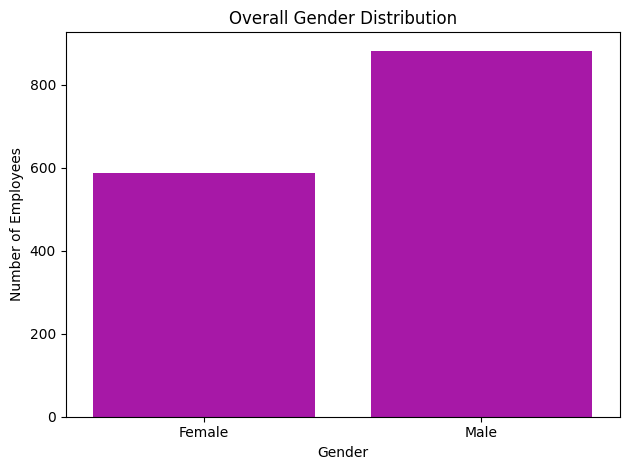

In [4]:
plt.title('Overall Gender Distribution')
sns.countplot(data=df, x='Gender',color='m')
plt.title('Overall Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

 **Overall Gender Imbalance**:

 Based on the 'Gender Distribution by Department' bar plot and the numerical breakdown from df['Gender'].value_counts(normalize=True)*100:

 The company generally has more male employees (60%) than female employees (40%). This overall imbalance is reflected, to varying degrees, the following will check the distribution across the departments and leadership roles.


## Gender Distribution by Department

In [5]:
pd.crosstab(df['Department'],df['Gender'],normalize=True)*100

Gender,Female,Male
Department,,
Human Resources,1.360544,2.925170
Research & Development,25.782313,39.591837
Sales,12.857143,17.482993


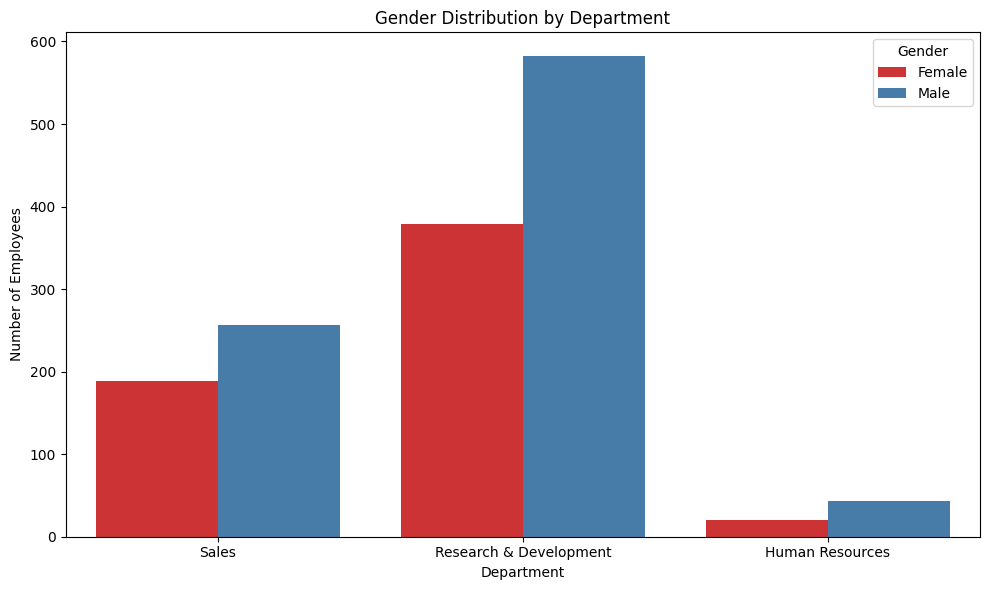

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Department', hue='Gender',palette='Set1')
plt.title('Gender Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()



### Gender Distribution by Department Summary

Based on the 'Gender Distribution by Department' bar plot and the numerical breakdown from `pd.crosstab(df['Department'],df['Gender'],normalize=True)*100`:

 Across all departments, there is a consistent trend of more male employees than female employees. The Research & Development and Sales departments, being the largest, naturally show higher absolute numbers for both genders, but the *proportional* dominance of males is evident across all three departments. There are no departments observed where the gender distribution is relatively balanced, highlighting a company-wide gender imbalance in favor of male employees.

## Leadership Representation

In [7]:
df[df['IsLeader']==1]['Gender'].value_counts(normalize=True)*100

,proportion
Gender,
Male,53.51682
Female,46.48318




Among employees in leadership roles (`IsLeader == 1`), males constitute **53.52%** and females represent **46.48%**. While the gap is narrower than the overall company gender distribution, there is still a slight male dominance in leadership positions.

## Leadership Level Representaion

In [8]:
pd.crosstab(df['leadership_level'],df['Gender'],normalize='index')*100

Gender,Female,Male
leadership_level,,
Director,46.666667,53.333333
Individual Contributor,38.145232,61.854768
Manager,46.078431,53.921569


In [9]:
femaleWorkforce = (df['Gender']=='Female').mean()*100
femaleLeadership=df[df['IsLeader']==1]['Gender'].value_counts(normalize=True)['Female']*100
femaleWorkforce-femaleLeadership

np.float64(-6.48318042813456)

Since the calculated value is negative, it indicates a positive trend where females are disproportionately more represented in leadership positions relative to thier over all presence in the company.


## Insights or Next Steps
*   The company has a significant gender imbalance favoring male employees across all departments and leadership roles.
*   It is recommended to investigate the underlying causes of this imbalance and explore strategies to promote greater gender diversity and balance within departments.


# Pay Equity Analysis

## Average & Median Salary

In [10]:
df.groupby('Gender')['MonthlyIncome'].agg(['mean','median'])

,mean,median
Gender,,
Female,6686.566327,5081.5
Male,6380.507937,4837.5


## Pay Gap Calulation

In [11]:
avgSal=df.groupby('Gender')['MonthlyIncome'].mean()

payGap = (((avgSal['Male']-avgSal['Female'])/avgSal['Male'])*100).round(2)
payGap

np.float64(4.8)

That way:

Positive → Males earn more

Negative → Females earn more

*   Female employees in the dataset show a higher average monthly income of 6,686.57, compared to 6,380.51 for male employees.
*   The median monthly income for female employees is 5,081.50, which is also higher than the 4,837.50 for male employees.
*   There is a calculated pay gap of 4.8%, indicating that, on average, female employees earn 4.8% more than male employees in this dataset.

## Salary Distribution

/tmp/ipython-input-1569/2905555885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


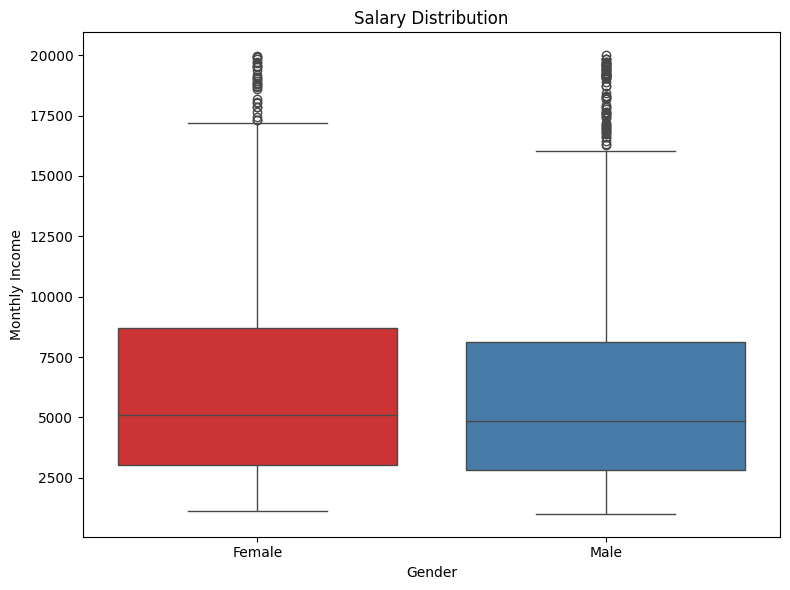

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='Gender',
    y='MonthlyIncome',
    palette='Set1'
)
plt.title('Salary Distribution')
plt.xlabel('Gender')
plt.ylabel('Monthly Income')
plt.tight_layout()




*   The salary distribution, as suggested by the box plot analysis, visually confirms the slightly higher median for females.
*   Both genders exhibit a similar spread of salaries (interquartile range), although the female distribution is noted to be slightly wider, suggesting marginally more variability in their middle salary ranges.
*   Significant upper outliers are present for both male and female employees, indicating high earners in both groups with similar maximum salary ranges.



## Department-Level Pay Gap





In [13]:
dept_pay_gap=df.groupby(['Department','Gender'])['MonthlyIncome'].mean().unstack()

In [21]:
dept_pay_gap['PayGap%']=(
   (
       (dept_pay_gap['Male']-dept_pay_gap['Female'])
       /dept_pay_gap['Male']
    )*100
).round(2)
dept_pay_gap

Gender,Female,Male,PayGap%
Department,,,
Human Resources,7264.000000,6371.023256,-14.02
Research & Development,6513.691293,6129.888316,-6.26
Sales,6972.126984,6949.645914,-0.32


While the company wide pay gap previously showed females earning 4.8% more than males overall, the department wise breakdown reveals significant variations. The pay gap favours females in all department, Humar resources than others.

# Additional KPIs Calcualtions:

## Promotion Metrics

In [15]:
df['RecentlyPromoted']=(df['YearsSinceLastPromotion']==0).astype(int)

## Promotion Rate by Gender

In [16]:
df.groupby('Gender')['RecentlyPromoted'].mean().round(2)*100

,RecentlyPromoted
Gender,
Female,39.0
Male,40.0


Promotion rate among females is slighlty lower than males. There is only 1% difference between both genders.

## Attrition Rate

### Overall Atrrition Rate

In [17]:
round((df['Attrition']=='Yes').mean()*100,2)

np.float64(16.12)

### Attrition by Gender

In [18]:
round(
    (df.groupby('Gender')
    ['Attrition'].apply(lambda x:(x=='Yes').mean()*100
)),2)

,Attrition
Gender,
Female,14.80
Male,17.01


Attrition by Tenure Band

In [19]:
df.groupby('TenureBand')['Attrition'].apply(lambda x:(x=='Yes').mean()*100).round(2)

,Attrition
TenureBand,
0-2 Years,29.82
11-20 Years,6.67
21-40 Years,12.12
3-5 Years,13.82
6-10 Years,12.28


• Attrition is highest among employees with tenure under 2 years.
• Overall male attrition rate is slightly higher than females.

# Insight Summary

Gender Representation:


*   The company generally has more male employees (60%) than female employees (40%).
*   The Research & Development and Sales departments, being the largest, naturally show higher absolute numbers for both genders, but the proportional dominance of males is evident across all three departments.

Pay Equity:


* Female employees in the dataset show a higher average monthly income of 6,686.57, compared to 6,380.51 for male employees.
* There is a calculated pay gap of 4.8%, indicating that, on average, female employees earn 4.8% more than male employees in this dataset.
* Both genders exhibit a similar spread of salaries (interquartile range), although the female distribution is noted to be slightly wider, suggesting marginally more variability in their middle salary ranges.
* The pay gap favours females in all department, Human resources than others followed by Research and development.




**While workforce representation is moderate, leadership inclusivity and department-level pay equity require further attention.**

In [20]:
df.to_csv('processed_hr_data_eda.csv',index=False)